## Import

In [6]:
from pathlib import Path
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
from xml.etree.ElementTree import fromstring, ElementTree
from Evtx.Evtx import Evtx
import csv

In [7]:
%load_ext autoreload
%autoreload 2
import preprocess
import main
import a
from unmask_attributes import process_csv

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
INTERIM_DIR = Path('../data/interim')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR = Path('../data/raw')
NO_MEANING_DIR = Path('../data/no_meaning')

# データ作成

### refine データ作成
- securityログ
- T1105, (VSCode1), WEB1, WEB2　を含む（12/28時点ではWEB2のアノマリーは含まず）
- integrated を流用

In [ ]:
df = pd.read_csv(INTERIM_DIR/"Integrated/security2_structured.csv") 

In [5]:
cond = (df["Label"] == "anomaly") & (df["project"] == "WEB2")

idx = df.index[cond]
if len(idx) > 0:
    df = df.loc[:idx[0]-1]
    
df.loc[df["project"] == "WEB2", "project"] = "WEB2_C"
df.to_csv(INTERIM_DIR/"refine/security2_structured.csv")

# 検証

## Windows

### 素

In [ ]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured.csv",
    output_dir = PROCESSED_DIR/"refine_time",
    window_size = 1800, # 30min
    step_size = 900,
    mode = "time",
)

/home/siwamura/My_lad/src/preprocess.py:1006: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 3154 instances (sliding windows) in this dataset

there are 864 instances (sliding windows) in this dataset

there are 1100 instances (sliding windows) in this dataset

there are 805 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine_time/ratio_0.8/train_projects.csv
Project info saved to ../data/processed/refine_time/ratio_0.8/test_normal_projects.csv
Project info saved to ../data/processed/refine_time/ratio_0.8/test_abnormal_projects.csv
Project info saved to ../data/processed/refine_time/vocab/train_projects.csv
vocab size 5620
Sequence Length Statistics Report
Generated: 2025-12-21 21:57:25
Mode: time
Window Size: 1800
Step Size: 900

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    4,496
    Avg Len:  461.97
    Min Len:  97
    Max Len:  22258
    Std Dev:  479.56
  test_normal:
    Count:    1,124
    Avg Len:  481.16
    Min Len:  5
    Max Len:  21798
    Std Dev:  725.68
  test_abnormal:


In [ ]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured.csv",
    output_dir = PROCESSED_DIR/"refine_fixed",
    window_size = 430, # 時間ベースの分割における平均値を採用(サンプル数が5000前後になるように調整)
    step_size = 200,
    mode = "fixed",
)

/home/siwamura/My_lad/src/preprocess.py:1006: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine_fixed/ratio_0.8/train_projects.csv
Project info saved to ../data/processed/refine_fixed/ratio_0.8/test_normal_projects.csv
Project info saved to ../data/processed/refine_fixed/ratio_0.8/test_abnormal_projects.csv
Project info saved to ../data/processed/refine_fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2025-12-22 00:47:45
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
  

### unmask & MD5

In [10]:
process_csv(
    input_csv_path=INTERIM_DIR/'refine/security2_structured.csv',
    output_csv_path=INTERIM_DIR/'refine/security2_structured_unmasked.csv',
    no_mask_config="no_mask.json",
    new_column_name='EventTemplateUnmasked',
    hash_method="md5",
)

Loading no_mask config from: no_mask.json
Loading CSV from: ../data/interim/refine/security2_structured.csv
Total rows: 1366109
Columns: ['LineId', 'Level', 'EventID', 'EventRecordID', 'TimeCreated_SystemTime', 'Channel', 'Task', 'Provider_Name', 'Correlation_RelatedActivityID', 'Execution_ProcessID', 'Execution_ThreadID', 'Security_UserID', 'Keywords', 'Content', 'Correlation_ActivityID', 'Provider_Guid', 'Computer', 'Opcode', 'Version', 'Label', 'date', 'project', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['SubjectUserSid', 'NewProcessName', 'CommandLine']
  Found 39423 rows with EventID=4688

Processing EventID: 5156, Attributes: ['Application', 'DestPort']
  Found 685614 rows with EventID=5156

Generating MD5 hash column: EventTemplateUnmaskedHash_md5
  Hash column created with 1366109 values (MD5)

Saving result to: ../data/interim/refine/security2_structured_unmasked.csv
Done!

--- Sample of unmasked data ---

EventID 4688:
  Original: SubjectUserSid=<*>|

In [11]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR/"refine2/fixed",
    event_id="EventTemplateUnmaskedHash_md5",
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed",
)

/home/ubuntu/My_lad/src/preprocess.py:1008: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine2/fixed/train_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_normal_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_abnormal_projects.csv
Project info saved to ../data/processed/refine2/fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2025-12-31 16:03:44
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Le

### unmask & LSH

In [15]:
process_csv(
    input_csv_path=INTERIM_DIR/'refine/security2_structured.csv',
    output_csv_path=INTERIM_DIR/'refine/security2_structured_unmasked.csv',
    no_mask_config="no_mask.json",
    new_column_name='EventTemplateUnmasked',
    hash_method="lsh",
    use_multiprocess=True
)


Loading no_mask config from: no_mask.json
Loading CSV from: ../data/interim/refine/security2_structured.csv
Total rows: 1366109
Columns: ['LineId', 'Level', 'EventID', 'EventRecordID', 'TimeCreated_SystemTime', 'Channel', 'Task', 'Provider_Name', 'Correlation_RelatedActivityID', 'Execution_ProcessID', 'Execution_ThreadID', 'Security_UserID', 'Keywords', 'Content', 'Correlation_ActivityID', 'Provider_Guid', 'Computer', 'Opcode', 'Version', 'Label', 'date', 'project', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['SubjectUserSid', 'NewProcessName', 'CommandLine']
  Found 39423 rows with EventID=4688

Processing EventID: 5156, Attributes: ['Application', 'DestPort']
  Found 685614 rows with EventID=5156

Generating LSH (GPU) hash column: EventTemplateUnmaskedHash_lsh
  GPU LSH Progress: 100000/1366109 (7.3%)
  GPU LSH Progress: 200000/1366109 (14.6%)
  GPU LSH Progress: 300000/1366109 (22.0%)
  GPU LSH Progress: 400000/1366109 (29.3%)
  GPU LSH Progress: 500000/13661

In [16]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR/"refine2/fixed",
    event_id="EventTemplateUnmaskedHash_lsh",
    features = ["EventTemplateUnmaskedHash_lsh", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_lsh", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed",
)

/home/ubuntu/My_lad/src/preprocess.py:1008: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine2/fixed/train_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_normal_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_abnormal_projects.csv
Project info saved to ../data/processed/refine2/fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2025-12-31 16:30:54
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Le

### テスト実行部

In [ ]:
# train
main.main_cli([
    "train",
    "bert/refine2",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

In [18]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/refine2/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
])

../outputs/logbert/bert_no_time/refine2/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 6573/6573 [00:00<00:00, 17228.11it/s]


VOCAB SIZE: 2721
Updated vocab_size to 2721


100%|██████████| 251/251 [00:01<00:00, 163.73it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['1278.0000', '247.0000', '34.0000', '4.0000', '16.1967', '98.4064', '27.8153', '98.4064', '97.4085']
threshold=0.100['493.0000', '108.0000', '819.0000', '143.0000', '17.9700', '43.0279', '25.3521', '43.0279', '37.5762']
threshold=0.200['112.0000', '60.0000', '1200.0000', '191.0000', '34.8837', '23.9044', '28.3688', '23.9044', '8.5366']
threshold=0.300['43.0000', '40.0000', '1269.0000', '211.0000', '48.1928', '15.9363', '23.9521', '15.9363', '3.2774']
threshold=0.400['20.0000', '17.0000', '1292.0000', '234.0000', '45.9459', '6.7729', '11.8056', '6.7729', '1.5244']
threshold=0.500['14.0000', '9.0000', '1298.0000', '242.0000', '39.1304', '3.5857', '6.5693', '3.5857', '1.0671']
threshold=0.600['10.0000', '7.0000', '1302.0000', '244.0000', '41.1765', '2.7888', '5.2239', '2.7888', '0.7622']
threshold=0.700['8.0000', '4.0000', '1304.0000', '247.0000', '33.3333', '1

### 可視化（archive参照）：

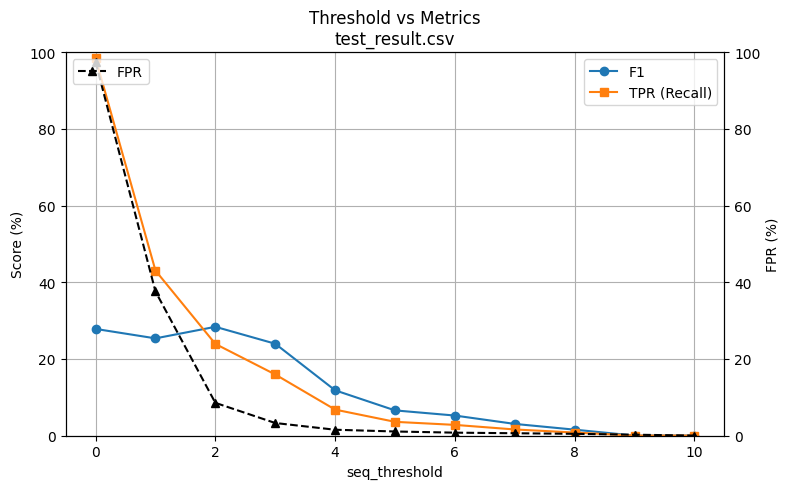

In [19]:
a.plot_threshold_metrics(Path("../archive/4/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

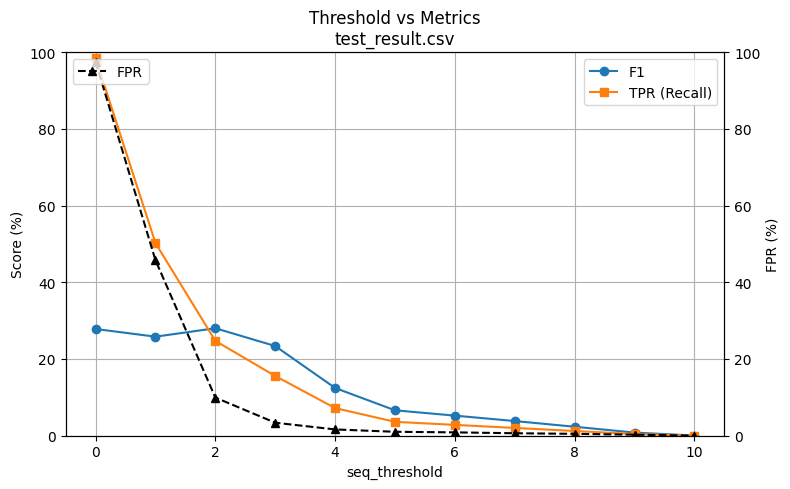

In [14]:
a.plot_threshold_metrics(Path("../archive/3/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

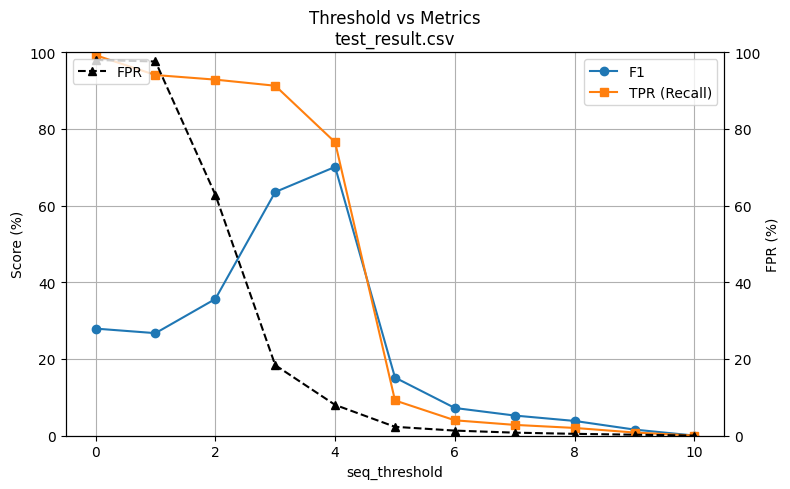

In [9]:
a.plot_threshold_metrics(Path("../archive/2/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

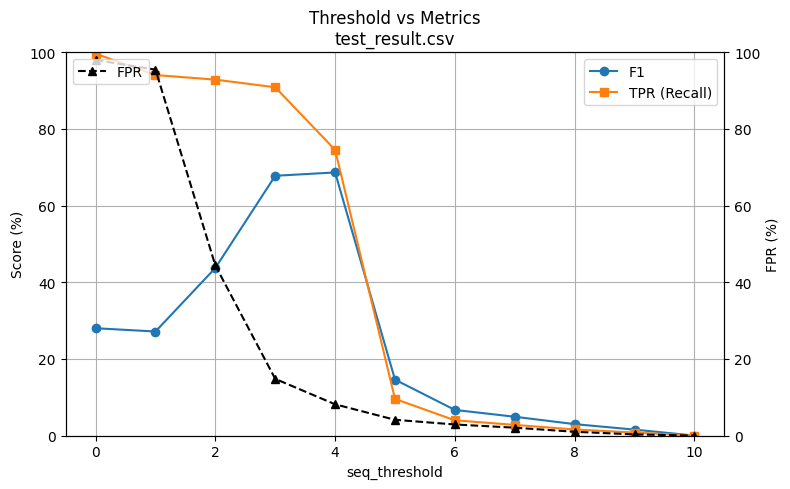

In [9]:
a.plot_threshold_metrics(Path("../archive/1/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

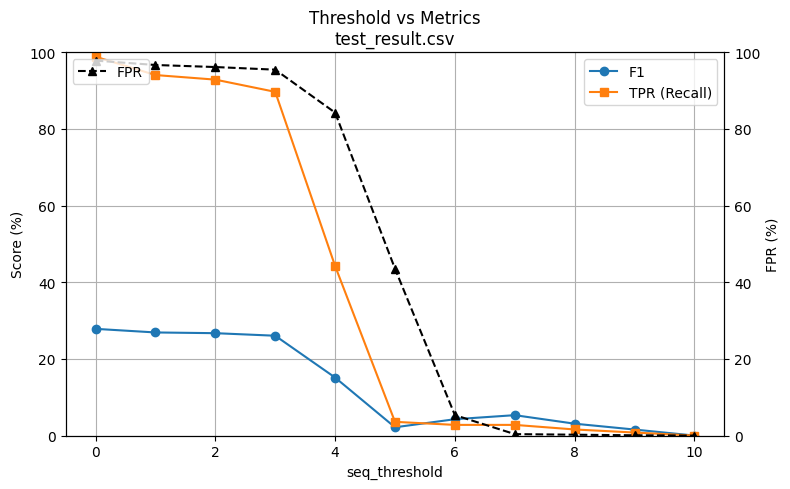

In [ ]:
a.plot_threshold_metrics(Path("../archive/0/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

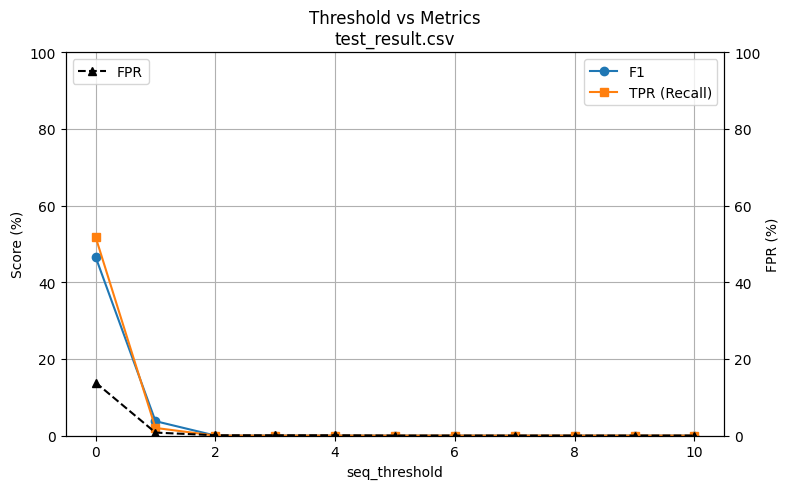

In [8]:
a.plot_threshold_metrics(Path("../output/logbert/bert/refine/fixed/seq_len_512/r_seed_31/test_result.csv"))

## BGL

In [ ]:
preprocess.prepare_bgl_model_data(
    logdata_filepath = INTERIM_DIR/"BGL/BGL_structured.csv",
    output_dir = PROCESSED_DIR/"BGL",
    window_size = 300, # 時間ベースの分割における平均値を採用
    step_size = 60,
    mode = "time",
)

In [17]:
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"BGL/ratio_0.8/train_full"),
    output_file=Path(PROCESSED_DIR/"BGL/ratio_0.8/train")
)

In [ ]:
# train
main.main_cli([
    "train",
    "bert/bgl",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

In [12]:
# テスト
main.main_cli([
    "test",  # run_mode
    "outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "64",   # eval_batchsize
    "cuda:0",     # gpu
])

outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 16268/16268 [00:01<00:00, 9993.12it/s] 


VOCAB SIZE: 237


Processing abnormal test data: 100%|██████████| 2584/2584 [00:01<00:00, 1433.51it/s]


Building Vocab


100%|██████████| 16268/16268 [00:01<00:00, 10361.58it/s]


VOCAB SIZE: 237


100%|██████████| 2584/2584 [00:14<00:00, 179.13it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['860.0000', '2578.0000', '2340.0000', '6.0000', '74.9855', '99.7678', '85.6194', '99.7678', '26.8750']
threshold=0.100['558.0000', '2333.0000', '2642.0000', '251.0000', '80.6987', '90.2864', '85.2237', '90.2864', '17.4375']
threshold=0.200['460.0000', '2185.0000', '2740.0000', '399.0000', '82.6087', '84.5588', '83.5724', '84.5588', '14.3750']
threshold=0.300['417.0000', '2038.0000', '2783.0000', '546.0000', '83.0143', '78.8700', '80.8891', '78.8700', '13.0312']
threshold=0.400['390.0000', '1894.0000', '2810.0000', '690.0000', '82.9247', '73.2972', '77.8143', '73.2972', '12.1875']
threshold=0.500['338.0000', '1792.0000', '2862.0000', '792.0000', '84.1315', '69.3498', '76.0289', '69.3498', '10.5625']
threshold=0.600['270.0000', '1688.0000', '2930.0000', '896.0000', '86.2104', '65.3251', '74.3285', '65.3251', '8.4375']
threshold=0.700['263.0000', '1593.0000', '

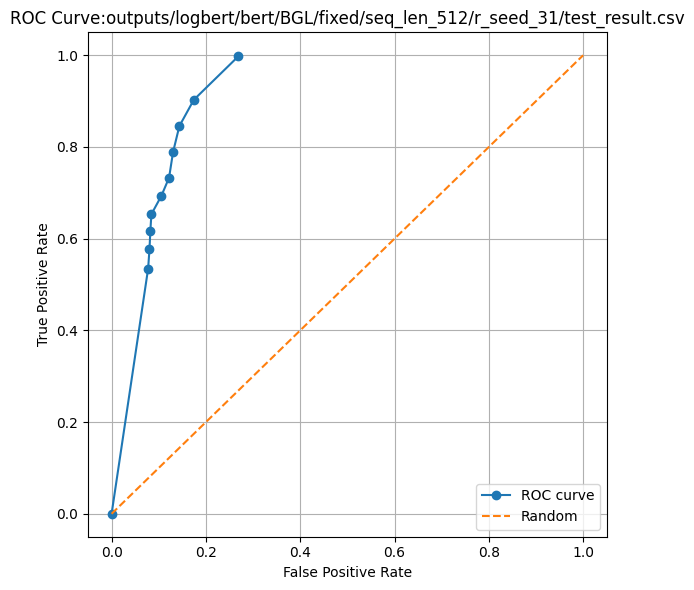

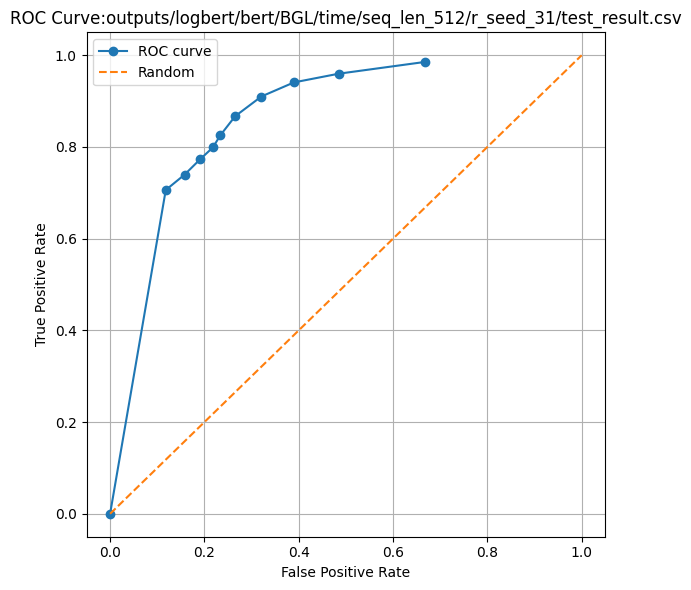

In [19]:
a.plot_roc(Path("outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31/test_result.csv"))
a.plot_roc(Path("outputs/logbert/bert/BGL/time/seq_len_512/r_seed_31/test_result.csv"))


## Tbird

In [28]:
preprocess.prepare_tbird_model_data(
    logdata_filepath = INTERIM_DIR/"Tbird/Thunderbird_structured.csv",
    output_dir = PROCESSED_DIR/"Tbird/fixed",
    window_size = 300, 
    step_size = 150,
    mode = "fixed",
)

/home/siwamura/My_lad/src/preprocess.py:1286: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['deltaT'].fillna(0, inplace=True)


there are 133332 instances (sliding windows) in this dataset

vocab size 79166
Sequence Length Statistics Report
Generated: 2025-12-21 19:40:07
Mode: fixed
Window Size: 300
Step Size: 150

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    63,332
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00
  test_normal:
    Count:    15,834
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00
  test_abnormal:
    Count:    54,166
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00


Statistics saved to: ../data/processed/Tbird/fixed/seq_stats.txt


In [29]:
# サンプル数を5000まで削る
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"Tbird/fixed/train_full"),
    output_file=Path(PROCESSED_DIR/"Tbird/fixed/train")
)

In [30]:
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"Tbird/fixed/test_abnormal_full"),
    output_file=Path(PROCESSED_DIR/"Tbird/fixed/test_abnormal")
)

In [ ]:
# train
main.main_cli([
    "train",
    "bert/tbird",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

In [33]:
# テスト
main.main_cli([
    "test",  # run_mode
    "outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "64",   # eval_batchsize
    "cuda:0",     # gpu
])

outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 79166/79166 [00:04<00:00, 16982.03it/s]


VOCAB SIZE: 1159


100%|██████████| 44892/44892 [03:57<00:00, 188.98it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['12613.0000', '44824.0000', '3195.0000', '68.0000', '78.0403', '99.8485', '87.6076', '99.8485', '79.7887']
threshold=0.100['10273.0000', '44351.0000', '5535.0000', '541.0000', '81.1932', '98.7949', '89.1334', '98.7949', '64.9861']
threshold=0.200['9062.0000', '43545.0000', '6746.0000', '1347.0000', '82.7742', '96.9995', '89.3240', '96.9995', '57.3254']
threshold=0.300['8233.0000', '42231.0000', '7575.0000', '2661.0000', '83.6854', '94.0724', '88.5754', '94.0724', '52.0812']
threshold=0.400['7538.0000', '37227.0000', '8270.0000', '7665.0000', '83.1610', '82.9257', '83.0432', '82.9257', '47.6847']
threshold=0.500['6882.0000', '28790.0000', '8926.0000', '16102.0000', '80.7076', '64.1317', '71.4711', '64.1317', '43.5349']
threshold=0.600['6245.0000', '22850.0000', '9563.0000', '22042.0000', '78.5358', '50.8999', '61.7676', '50.8999', '39.5053']
threshold=0.700['

/home/siwamura/My_lad/src/a.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  tpr = df["TPR"] / 100.0
/home/siwamura/My_lad/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


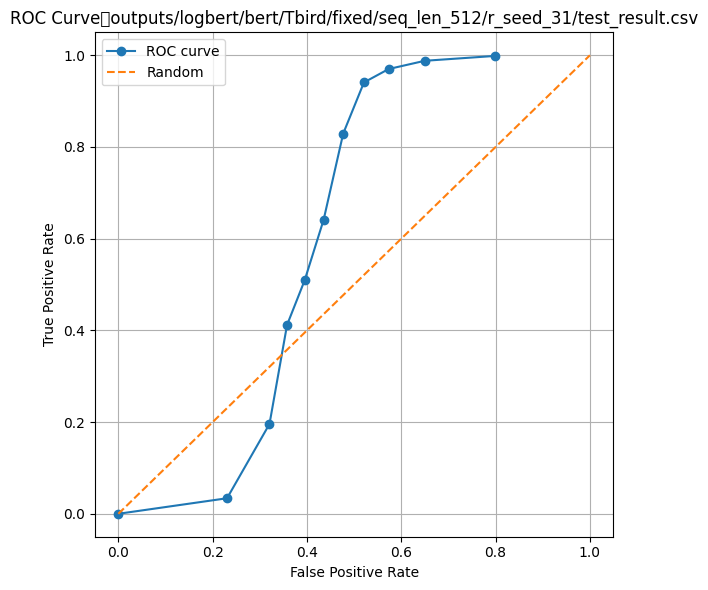

/home/siwamura/My_lad/src/a.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  tpr = df["TPR"] / 100.0
/home/siwamura/My_lad/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


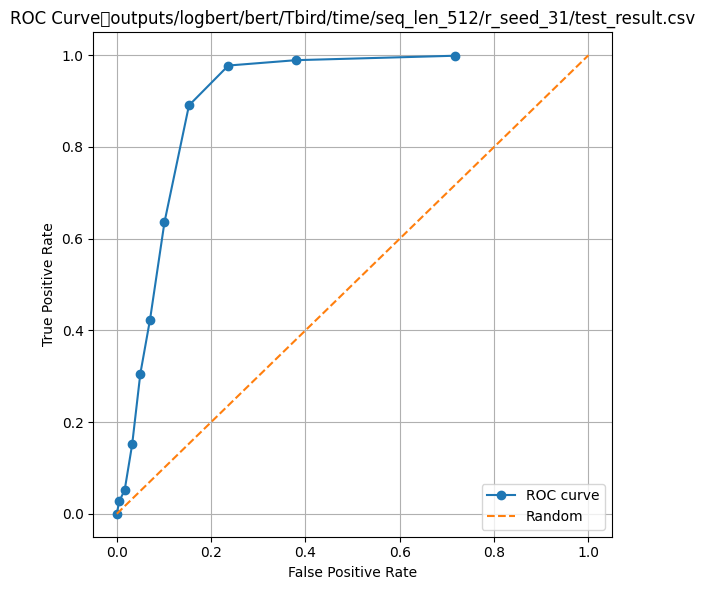

In [43]:
a.plot_roc(Path("outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31/test_result.csv"))
a.plot_roc(Path("outputs/logbert/bert/Tbird/time/seq_len_512/r_seed_31/test_result.csv"))
